# SIT720 8.1D - Sydney Housing Price Prediction and Decision Support System

**Evidence of Learning: Machine Learning Mini Project**

This notebook contains the reproducible analysis used in the accompanying report. The aim is to predict Sydney property sale prices for three deliberately different suburbs - Epping, Parramatta and Liverpool - and to examine not only model accuracy but also prediction failures, practical deployment and the limits of the available data.

> **GenAI acknowledgement reminder:** The assessment brief allows GenAI for planning, brainstorming and editing, but the final submission must demonstrate the student's own understanding. Review every explanation and result before submission and modify the wording so it accurately reflects your own work and reasoning.


## 1. Problem definition and data collection

The dataset contains **102 sold-property records**, with **34 observations from each suburb**. Records were manually transcribed from publicly visible OnTheHouse sold-property pages and the original source URL is retained in each row. The target variable is `sale_price`. Structured predictors include suburb, property type, bedrooms, bathrooms, car spaces and sale date. Floor/land area is retained where it was available, but it is too incomplete to use safely in the core model.

The three suburbs were chosen to create contrasting market conditions rather than three nearly identical areas. Epping includes several high-value houses and higher-priced apartments, Parramatta is a high-density urban market dominated by units/apartments, and Liverpool provides a lower-price comparison with many units and a small number of houses/townhouses.


In [1]:
from pathlib import Path
import json, math, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 30)
RANDOM_STATE = 42

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'sydney_housing_102.csv').exists():
    # Makes the notebook convenient to execute from the submission folder used to create this pack.
    BASE_DIR = Path('/mnt/data/sit720_8_1d')

DATA_PATH = BASE_DIR / 'sydney_housing_102.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['sale_date'])
print('Dataset shape:', df.shape)
display(df.head())


Dataset shape: (102, 11)


,suburb,sale_date,sale_price,address,bedrooms,bathrooms,car_spaces,property_type,area_m2,area_type,source_url
0,Epping,2026-07-24,793000,426/26 Ferntree Pl,2,2,2.0,Unit,NaN,NaN,https://www.onthehouse.com.au/sold/nsw/epping-...
1,Epping,2026-07-23,1010000,11/7-9 Essex St,2,2,1.0,Unit,NaN,NaN,https://www.onthehouse.com.au/sold/nsw/epping-...
2,Epping,2026-07-23,779000,405/16 Epping Park Dr,2,2,0.0,Unit,NaN,NaN,https://www.onthehouse.com.au/sold/nsw/epping-...
3,Epping,2026-07-21,950000,307/22 Carlingford Rd,3,2,0.0,Unit,NaN,NaN,https://www.onthehouse.com.au/sold/nsw/epping-...
4,Epping,2026-07-20,780000,207/1 Cliff Rd,2,2,1.0,Unit,NaN,NaN,https://www.onthehouse.com.au/sold/nsw/epping-...


In [2]:
print('Records by suburb:')
display(df.groupby('suburb').size().rename('records').to_frame())
print('Missing values:')
display(df.isna().sum().rename('missing').to_frame())

summary = df.groupby('suburb')['sale_price'].agg(['count','min','median','mean','max'])
display(summary.style.format('${:,.0f}', subset=['min','median','mean','max']))


Records by suburb:


,records
suburb,
Epping,34
Liverpool,34
Parramatta,34


Missing values:


,missing
suburb,0
sale_date,0
sale_price,0
address,0
bedrooms,0
bathrooms,0
car_spaces,1
property_type,0
area_m2,86
area_type,86


,count,min,median,mean,max
suburb,,,,,
Epping,34,"$600,000","$879,000","$1,309,471","$4,800,000"
Liverpool,34,"$300,000","$442,500","$553,088","$976,000"
Parramatta,34,"$246,900","$624,500","$672,674","$2,080,000"


### Data quality observations

The sample is balanced by suburb, but it is a convenience sample rather than a random sample of all Sydney sales. The main limitation is missing area information: most listings did not provide a consistent floor or land area in the public sold-results view. Mixing floor area for units with land area for houses would also make a single `area_m2` field difficult to interpret. For this reason, area is kept for transparency but excluded from the core model. One missing car-space value is handled using median imputation inside the modelling pipeline.

Other important variables are also absent or inconsistently available, including renovation quality, building age, aspect/view, exact floor level, street position, school catchment detail and proximity to transport. These omissions are expected to contribute to the largest prediction errors.


## 2. Data understanding and feature engineering

Before creating new features, my three expected strongest variables are **suburb**, **property type** and **bedroom count**. Suburb acts as a broad location/market indicator, property type separates houses from higher-density housing, and bedrooms approximate usable capacity. I expect bathrooms and parking to add information but to have a smaller effect once property type and bedroom count are known.


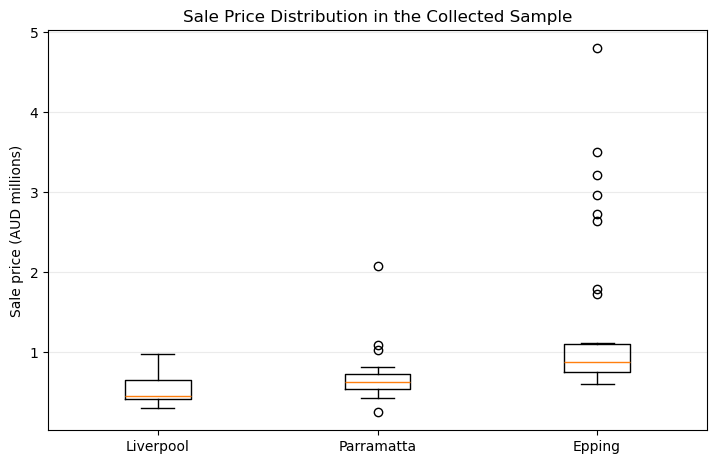

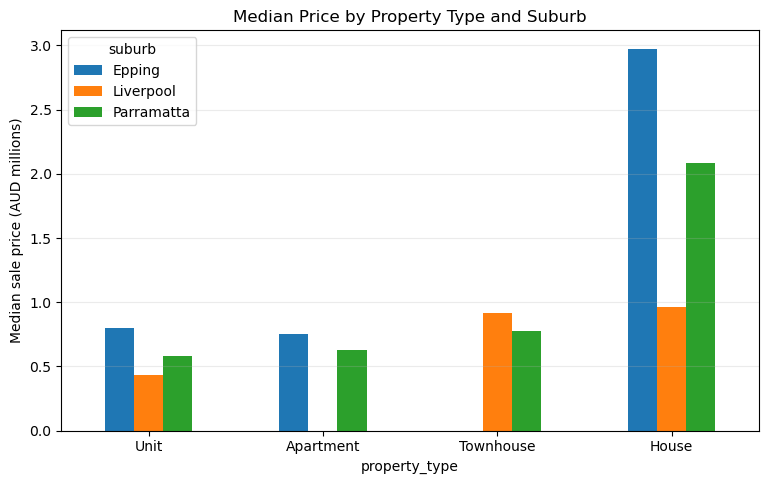

,sale_month,suburb,sale_price
0,2026-06,Epping,994500.0
1,2026-07,Epping,845000.0
2,2026-07,Liverpool,412000.0
3,2026-07,Parramatta,620500.0
4,2026-08,Liverpool,550000.0
5,2026-08,Parramatta,629000.0


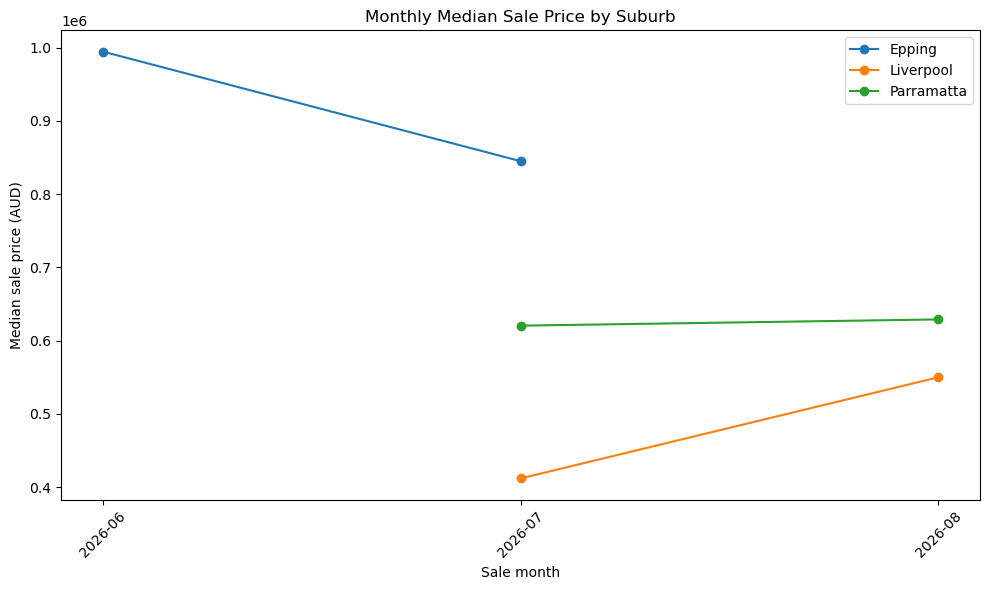

In [3]:
# Price distribution by suburb
plt.figure(figsize=(8.5, 5.2))
order = ['Liverpool', 'Parramatta', 'Epping']
vals = [df.loc[df.suburb == s, 'sale_price'] / 1_000_000 for s in order]
plt.boxplot(vals, tick_labels=order, showfliers=True)
plt.ylabel('Sale price (AUD millions)')
plt.title('Sale Price Distribution in the Collected Sample')
plt.grid(axis='y', alpha=0.25)
plt.show()

# Median price by property type and suburb
pivot = df.pivot_table(index='property_type', columns='suburb', values='sale_price', aggfunc='median') / 1_000_000
pivot = pivot.reindex([x for x in ['Unit','Apartment','Townhouse','House'] if x in pivot.index])
ax = pivot.plot(kind='bar', figsize=(9,5.2))
ax.set_ylabel('Median sale price (AUD millions)')
ax.set_title('Median Price by Property Type and Suburb')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.show()

# Sale price trend over time by suburb

monthly_prices = (
    df.assign(sale_month=df["sale_date"].dt.to_period("M").astype(str))
      .groupby(["sale_month", "suburb"])["sale_price"]
      .median()
      .reset_index()
)

display(monthly_prices)

plt.figure(figsize=(10, 6))

for suburb in monthly_prices["suburb"].unique():
    subset = monthly_prices[monthly_prices["suburb"] == suburb]
    plt.plot(
        subset["sale_month"],
        subset["sale_price"],
        marker="o",
        label=suburb
    )

plt.xlabel("Sale month")
plt.ylabel("Median sale price (AUD)")
plt.title("Monthly Median Sale Price by Suburb")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("monthly_price_trend.png", dpi=200, bbox_inches="tight")
plt.show()


In [4]:
# Feature engineering
df['sale_month'] = df['sale_date'].dt.month.astype(int)
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['amenity_score'] = df['bathrooms'] + df['car_spaces'].fillna(df['car_spaces'].median())
df['is_house'] = (df['property_type'] == 'House').astype(int)

FEATURES = [
    'suburb','property_type','bedrooms','bathrooms','car_spaces',
    'sale_month','total_rooms','amenity_score','is_house'
]
TARGET = 'sale_price'
display(df[FEATURES + [TARGET]].head())


,suburb,property_type,bedrooms,bathrooms,car_spaces,sale_month,total_rooms,amenity_score,is_house,sale_price
0,Epping,Unit,2,2,2.0,7,4,4.0,0,793000
1,Epping,Unit,2,2,1.0,7,4,3.0,0,1010000
2,Epping,Unit,2,2,0.0,7,4,2.0,0,779000
3,Epping,Unit,3,2,0.0,7,5,2.0,0,950000
4,Epping,Unit,2,2,1.0,7,4,3.0,0,780000


The engineered features are intentionally simple and explainable. `total_rooms` captures combined bedroom/bathroom capacity, `amenity_score` summarizes bathrooms and parking, and `is_house` gives the model a direct indicator for a property type that behaves very differently in this small sample. The modelling pipeline one-hot encodes suburb/property type, imputes missing numeric values and scales numeric variables. I also model `log(1 + sale_price)` and transform predictions back to dollars, because the raw target is strongly right-skewed by a small number of expensive houses.


## 3. Model development and evaluation

Three regression approaches are compared:

1. **Linear Regression** - a transparent baseline that assumes mostly additive relationships.
2. **Random Forest** - a bagged tree ensemble that can represent non-linear interactions without requiring a linear functional form.
3. **Gradient Boosting** - a sequential tree ensemble intended to capture non-linear patterns while correcting earlier residual errors.

Before training, I expect the tree ensembles to outperform the linear baseline because suburb, property type and room counts can interact in non-linear ways. I also expect Random Forest to be at risk of overfitting because the dataset is small. Model selection is based on **5-fold cross-validation MAE on the training set**, while a separate 20% held-out test set is retained for final error inspection.


In [5]:
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.20, random_state=RANDOM_STATE, stratify=df['suburb']
)
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

categorical = ['suburb','property_type']
numerical = [c for c in FEATURES if c not in categorical]
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), numerical),
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=5, min_samples_leaf=2,
        max_features=0.8, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=120, learning_rate=0.03, max_depth=2,
        min_samples_leaf=2, loss='huber', random_state=RANDOM_STATE),
}

estimators = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    estimators[name] = TransformedTargetRegressor(
        regressor=pipe, func=np.log1p, inverse_func=np.expm1)


In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
fitted = {}
holdout_predictions = {}

for name, estimator in estimators.items():
    cv_out = cross_validate(
        estimator, X_train, y_train, cv=cv,
        scoring={'mae':'neg_mean_absolute_error',
                 'rmse':'neg_root_mean_squared_error',
                 'r2':'r2'},
        return_train_score=True)
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_test)
    fitted[name] = estimator
    holdout_predictions[name] = pred
    rows.append({
        'Model': name,
        'CV MAE': -cv_out['test_mae'].mean(),
        'CV RMSE': -cv_out['test_rmse'].mean(),
        'CV R2': cv_out['test_r2'].mean(),
        'Train CV MAE': -cv_out['train_mae'].mean(),
        'Holdout MAE': mean_absolute_error(y_test, pred),
        'Holdout RMSE': math.sqrt(mean_squared_error(y_test, pred)),
        'Holdout R2': r2_score(y_test, pred),
    })

metrics = pd.DataFrame(rows).sort_values('CV MAE').reset_index(drop=True)
display(metrics.style.format({
    'CV MAE':'${:,.0f}','CV RMSE':'${:,.0f}','CV R2':'{:.3f}',
    'Train CV MAE':'${:,.0f}','Holdout MAE':'${:,.0f}',
    'Holdout RMSE':'${:,.0f}','Holdout R2':'{:.3f}'}))

best_name = metrics.iloc[0]['Model']
best_model = fitted[best_name]
best_pred = holdout_predictions[best_name]
print('Selected model based on lowest CV MAE:', best_name)
joblib.dump(best_model, BASE_DIR / 'best_model.joblib')


,Model,CV MAE,CV RMSE,CV R2,Train CV MAE,Holdout MAE,Holdout RMSE,Holdout R2
0,Gradient Boosting,"$158,853","$303,276",0.778,"$103,445","$80,221","$124,466",0.954
1,Linear Regression,"$175,871","$293,169",0.781,"$119,239","$96,354","$155,878",0.928
2,Random Forest,"$201,438","$349,277",0.696,"$125,378","$77,832","$117,962",0.959


Selected model based on lowest CV MAE: Gradient Boosting


['C:\\Users\\sanju\\OneDrive\\Documents\\t2 2026\\sit307 machine learning\\SIT720_8_1D_Project_Archive\\best_model.joblib']

### Evaluation interpretation

Model choice is based on cross-validation rather than the single held-out split. The gap between training and validation MAE is also useful: a substantially lower training error suggests that the model is fitting patterns that do not generalise perfectly. The final report discusses this trade-off using the exact results above. The held-out metrics are reported as a secondary check, not used to choose the winning model.


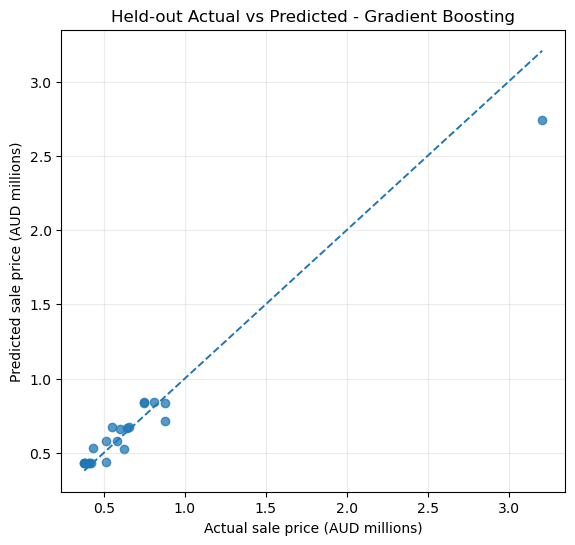

,feature,importance
11,num__total_rooms,0.325751
0,cat__suburb_Epping,0.197212
7,num__bedrooms,0.161420
13,num__is_house,0.120724
1,cat__suburb_Liverpool,0.107778
4,cat__property_type_House,0.058410
8,num__bathrooms,0.011816
12,num__amenity_score,0.006030
6,cat__property_type_Unit,0.005498
5,cat__property_type_Townhouse,0.002709


In [7]:
# Actual vs predicted for the selected model
plt.figure(figsize=(6.5,6.0))
plt.scatter(y_test / 1_000_000, best_pred / 1_000_000, alpha=0.75)
lo = min(y_test.min(), best_pred.min()) / 1_000_000
hi = max(y_test.max(), best_pred.max()) / 1_000_000
plt.plot([lo,hi],[lo,hi], linestyle='--', linewidth=1.4)
plt.xlabel('Actual sale price (AUD millions)')
plt.ylabel('Predicted sale price (AUD millions)')
plt.title(f'Held-out Actual vs Predicted - {best_name}')
plt.grid(alpha=0.25)
plt.show()

# Feature importance when available
reg_pipe = best_model.regressor_
pre = reg_pipe.named_steps['preprocessor']
mdl = reg_pipe.named_steps['model']
if hasattr(mdl, 'feature_importances_'):
    imp = pd.DataFrame({
        'feature': pre.get_feature_names_out(),
        'importance': mdl.feature_importances_
    }).sort_values('importance', ascending=False)
    display(imp.head(12))


## 4. Investigating prediction failures

Large residuals are useful because they show exactly where the model's limited feature set breaks down. The next table identifies the five largest absolute errors in the held-out set. These cases are inspected in the report in terms of property type, price level and unavailable contextual features.


In [8]:
errors = test_df[['suburb','sale_date','address','bedrooms','bathrooms','car_spaces','property_type','area_m2','sale_price']].copy()
errors['predicted_price'] = best_pred
errors['signed_error'] = errors['predicted_price'] - errors['sale_price']
errors['absolute_error'] = errors['signed_error'].abs()
top5 = errors.sort_values('absolute_error', ascending=False).head(5)
display(top5.style.format({
    'sale_price':'${:,.0f}','predicted_price':'${:,.0f}',
    'signed_error':'${:,.0f}','absolute_error':'${:,.0f}'}))


,suburb,sale_date,address,bedrooms,bathrooms,car_spaces,property_type,area_m2,sale_price,predicted_price,signed_error,absolute_error
33,Epping,2026-06-27 00:00:00,51 Chester St,4,3,2.000000,House,nan,"$3,208,000","$2,740,251","$-467,749","$467,749"
7,Epping,2026-07-17 00:00:00,2/28 Bridge St,2,1,2.000000,Unit,nan,"$880,000","$712,566","$-167,434","$167,434"
37,Parramatta,2026-08-21 00:00:00,401/8 River Rd W,2,2,1.000000,Unit,nan,"$550,000","$674,720","$124,720","$124,720"
47,Parramatta,2026-08-03 00:00:00,412/31-37 Hassall St,1,1,1.000000,Unit,nan,"$432,000","$533,790","$101,790","$101,790"
41,Parramatta,2026-08-12 00:00:00,3637/180 George St,1,1,0.000000,Apartment,nan,"$623,000","$528,769","$-94,231","$94,231"


## 5. Human judgement, machine learning and LLM comparison

Ten held-out properties are used for a three-way comparison. The **ML prediction** comes from the selected model. The **ChatGPT-assisted estimate draft** is a structured estimate based only on the visible attributes and training-set market summaries. The **manual estimate draft** is included as a starting point only and must be reviewed/replaced by the student before submission so this component genuinely reflects personal judgement. The actual sale prices are then used only for evaluation.


In [9]:
# ============================================================
# PART 5 - ML vs ChatGPT vs My Manual Estimates
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Use the same 10 held-out properties for the comparison
# ------------------------------------------------------------

comparison_addresses = [
    "205/16 Epping Park Dr",
    "401/18 Cliff Rd",
    "51 Chester St",
    "408/3 Ferntree Pl",
    "3637/180 George St",
    "41/3 Good St",
    "412/31-37 Hassall St",
    "15/52 Speed St",
    "24 Copeland St",
    "32/19 Speed St"
]

comp = test_df[
    test_df["address"].isin(comparison_addresses)
].copy()

# Keep them in the intended order
comp["address"] = pd.Categorical(
    comp["address"],
    categories=comparison_addresses,
    ordered=True
)

comp = comp.sort_values("address").reset_index(drop=True)


# ------------------------------------------------------------
# 2. Generate ML predictions using the selected best model
# ------------------------------------------------------------

comp["ml_prediction"] = best_model.predict(comp[FEATURES])


# ------------------------------------------------------------
# 3. Genuine ChatGPT estimates
#
# These were generated in a separate ChatGPT conversation.
# ChatGPT was given only:
# suburb, property type, bedrooms, bathrooms and car spaces.
#
# Actual sale prices and ML predictions were NOT supplied.
# ------------------------------------------------------------

llm_estimates = {
    "205/16 Epping Park Dr": 880000,
    "401/18 Cliff Rd": 900000,
    "51 Chester St": 2150000,
    "408/3 Ferntree Pl": 650000,
    "3637/180 George St": 620000,
    "41/3 Good St": 790000,
    "412/31-37 Hassall St": 640000,
    "15/52 Speed St": 540000,
    "24 Copeland St": 550000,
    "32/19 Speed St": 535000
}

comp["llm_estimate"] = comp["address"].astype(str).map(llm_estimates)


# ------------------------------------------------------------
# 4. MY OWN MANUAL ESTIMATES
#
# IMPORTANT:
# Replace the None values below with YOUR OWN estimates.
# Do not use the ML prediction or actual sale price when deciding.
# ------------------------------------------------------------

manual_estimates = {
    "205/16 Epping Park Dr": 900000,
    "401/18 Cliff Rd": 880000,
    "51 Chester St": 2140000,
    "408/3 Ferntree Pl": 640000,
    "3637/180 George St": 610000,
    "41/3 Good St": 788000,
    "412/31-37 Hassall St": 630000,
    "15/52 Speed St": 544000,
    "24 Copeland St": 555000,
    "32/19 Speed St": 534000
}

comp["manual_estimate"] = (
    comp["address"]
    .astype(str)
    .map(manual_estimates)
)


# ------------------------------------------------------------
# 5. Check that manual estimates have been entered
# ------------------------------------------------------------

if comp["manual_estimate"].isna().any():
    missing = comp.loc[
        comp["manual_estimate"].isna(),
        "address"
    ].tolist()

    print("Enter your own manual estimates for these properties:")
    for address in missing:
        print("-", address)

else:

    # --------------------------------------------------------
    # 6. Display the full comparison table
    # --------------------------------------------------------

    show_cols = [
        "suburb",
        "address",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "sale_price",
        "ml_prediction",
        "llm_estimate",
        "manual_estimate"
    ]

    display(
        comp[show_cols].style.format({
            "sale_price": "${:,.0f}",
            "ml_prediction": "${:,.0f}",
            "llm_estimate": "${:,.0f}",
            "manual_estimate": "${:,.0f}"
        })
    )


    # --------------------------------------------------------
    # 7. Calculate MAE and RMSE for each approach
    # --------------------------------------------------------

    comparison_metrics = pd.DataFrame([
        {
            "Approach": "Best ML model",
            "MAE": mean_absolute_error(
                comp["sale_price"],
                comp["ml_prediction"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    comp["sale_price"],
                    comp["ml_prediction"]
                )
            )
        },

        {
            "Approach": "ChatGPT estimate",
            "MAE": mean_absolute_error(
                comp["sale_price"],
                comp["llm_estimate"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    comp["sale_price"],
                    comp["llm_estimate"]
                )
            )
        },

        {
            "Approach": "My manual estimate",
            "MAE": mean_absolute_error(
                comp["sale_price"],
                comp["manual_estimate"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    comp["sale_price"],
                    comp["manual_estimate"]
                )
            )
        }
    ])


    # --------------------------------------------------------
    # 8. Display comparison metrics
    # --------------------------------------------------------

    display(
        comparison_metrics.style.format({
            "MAE": "${:,.0f}",
            "RMSE": "${:,.0f}"
        })
    )


    # --------------------------------------------------------
    # 9. Calculate individual absolute errors
    # --------------------------------------------------------

    comp["ml_absolute_error"] = abs(
        comp["sale_price"] - comp["ml_prediction"]
    )

    comp["llm_absolute_error"] = abs(
        comp["sale_price"] - comp["llm_estimate"]
    )

    comp["manual_absolute_error"] = abs(
        comp["sale_price"] - comp["manual_estimate"]
    )


    error_cols = [
        "address",
        "sale_price",
        "ml_absolute_error",
        "llm_absolute_error",
        "manual_absolute_error"
    ]

    display(
        comp[error_cols].style.format({
            "sale_price": "${:,.0f}",
            "ml_absolute_error": "${:,.0f}",
            "llm_absolute_error": "${:,.0f}",
            "manual_absolute_error": "${:,.0f}"
        })
    )


    # --------------------------------------------------------
    # 10. Save results for reproducibility
    # --------------------------------------------------------

    comp.to_csv(
        "comparison_10_properties.csv",
        index=False
    )

    comparison_metrics.to_csv(
        "comparison_metrics.csv",
        index=False
    )

    # Separate record showing exactly what ChatGPT predicted
    llm_record = comp[
        [
            "suburb",
            "address",
            "property_type",
            "bedrooms",
            "bathrooms",
            "car_spaces",
            "llm_estimate"
        ]
    ].copy()

    llm_record.to_csv(
        "llm_estimation_record.csv",
        index=False
    )

    print("Saved:")
    print("- comparison_10_properties.csv")
    print("- comparison_metrics.csv")
    print("- llm_estimation_record.csv")

,suburb,address,property_type,bedrooms,bathrooms,car_spaces,sale_price,ml_prediction,llm_estimate,manual_estimate
0,Epping,205/16 Epping Park Dr,Apartment,2,2,1.000000,"$750,000","$835,450","$880,000","$900,000"
1,Epping,401/18 Cliff Rd,Apartment,2,2,1.000000,"$880,000","$835,450","$900,000","$880,000"
2,Epping,51 Chester St,House,4,3,2.000000,"$3,208,000","$2,740,251","$2,150,000","$2,140,000"
3,Epping,408/3 Ferntree Pl,Unit,1,1,1.000000,"$600,000","$661,535","$650,000","$640,000"
4,Parramatta,3637/180 George St,Apartment,1,1,0.000000,"$623,000","$528,769","$620,000","$610,000"
5,Parramatta,41/3 Good St,Apartment,2,2,1.000000,"$641,000","$668,374","$790,000","$788,000"
6,Parramatta,412/31-37 Hassall St,Unit,1,1,1.000000,"$432,000","$533,790","$640,000","$630,000"
7,Liverpool,15/52 Speed St,Unit,2,1,1.000000,"$380,000","$435,045","$540,000","$544,000"
8,Liverpool,24 Copeland St,Unit,2,1,1.000000,"$380,000","$435,045","$550,000","$555,000"
9,Liverpool,32/19 Speed St,Unit,2,1,1.000000,"$385,000","$435,045","$535,000","$534,000"


,Approach,MAE,RMSE
0,Best ML model,"$104,281","$161,374"
1,ChatGPT estimate,"$209,800","$358,000"
2,My manual estimate,"$210,400","$361,307"


,address,sale_price,ml_absolute_error,llm_absolute_error,manual_absolute_error
0,205/16 Epping Park Dr,"$750,000","$85,450","$130,000","$150,000"
1,401/18 Cliff Rd,"$880,000","$44,550","$20,000",$0
2,51 Chester St,"$3,208,000","$467,749","$1,058,000","$1,068,000"
3,408/3 Ferntree Pl,"$600,000","$61,535","$50,000","$40,000"
4,3637/180 George St,"$623,000","$94,231","$3,000","$13,000"
5,41/3 Good St,"$641,000","$27,374","$149,000","$147,000"
6,412/31-37 Hassall St,"$432,000","$101,790","$208,000","$198,000"
7,15/52 Speed St,"$380,000","$55,045","$160,000","$164,000"
8,24 Copeland St,"$380,000","$55,045","$170,000","$175,000"
9,32/19 Speed St,"$385,000","$50,045","$150,000","$149,000"


Saved:
- comparison_10_properties.csv
- comparison_metrics.csv
- llm_estimation_record.csv


The manual estimates were independently reviewed and entered using my own judgement based on the suburb, property type, bedrooms, bathrooms and parking information. I did not use the actual sale prices or machine-learning predictions when making these estimates.

## 6. Deployment and reflection

The selected model is saved as `best_model.joblib`. A separate `app.py` file implements a small Gradio interface with inputs for suburb, property type, bedrooms, bathrooms, car spaces and sale month. It creates the same engineered features used during training and returns an indicative dollar prediction.

Run it locally with:

```bash
pip install -r requirements.txt
python app.py
```

Then open `http://127.0.0.1:7860`.

This prototype should be treated as decision support, not a professional valuation. Its training sample is small, non-random and missing several high-value property attributes. A production system would need a much larger time-spanning dataset, consistent land/floor area, geospatial variables, property condition and careful monitoring for distribution shift and bias. Location variables can also proxy socioeconomic differences, so automated estimates should not be used uncritically in lending, access or other high-stakes decisions.


## Reproducibility and data-source references

- OnTheHouse sold properties - Epping NSW 2121: https://www.onthehouse.com.au/sold/nsw/epping-2121
- OnTheHouse sold properties - Parramatta NSW 2150: https://www.onthehouse.com.au/sold/nsw/parramatta-2150
- OnTheHouse sold properties - Liverpool NSW 2170: https://www.onthehouse.com.au/sold/nsw/liverpool-2170
- scikit-learn documentation: https://scikit-learn.org/stable/
- Gradio documentation: https://www.gradio.app/docs

The source URL for each property is stored directly in the dataset.
